# Applied Artificial Intelligence (COMP40511)
## Coursework: Application of AI in Solving Real-World Problems
**Project Title:** Multi-Model Agricultural Classification: Deep Learning, Ensembles, and Unsupervised Clustering for Apple Leaf Disease Detection

**Student Name:** [Your Name]

**Student ID:** [Your ID]

### Project Overview & Proposal
This notebook contains the complete implementation of the Python source code for the COMP40511 coursework assessment. The goal is to detect and classify diseases in apple leaves using four distinct AI techniques as specified in the coursework guidelines, plus advanced extensions to optimize performance:
1. **Task 1: Multilayer Perceptron (MLP)** (using Keras/TensorFlow)
2. **Task 2: Ensemble Model** (using Scikit-Learn)
3. **Task 3: Deep Convolutional Neural Network (CNN)** (using Keras/TensorFlow)
   - *Advanced Extension:* Transfer Learning using pre-trained **MobileNetV2**
4. **Task 4: Clustering** (using Scikit-Learn K-Means)
   - *Advanced Extension 1:* Clustering on **PCA-reduced features**
   - *Advanced Extension 2:* **Deep Feature Clustering** (using MobileNetV2 embeddings)

The dataset consists of apple leaf images categorized into four classes:
- `Apple___Apple_scab`
- `Apple___Black_rot`
- `Apple___Cedar_apple_rust`
- `Apple___healthy`

## 1. Environment Setup and Imports

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2

# TensorFlow and Keras imports
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, Input, GlobalAveragePooling2D
from tensorflow.keras.utils import to_categorical

# Scikit-Learn imports
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.preprocessing import StandardScaler

# Set seeds for reproducibility
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

# Configure directories
DATASET_DIR = './dataset'
OUTPUTS_DIR = './outputs'
MODELS_DIR = './models'
os.makedirs(OUTPUTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print("TensorFlow version:", tf.__version__)
print("Environment initialized successfully.")

TensorFlow version: 2.21.0
Environment initialized successfully.


## 2. Data Loading and Preprocessing

In [3]:
CLASSES = ["Apple___Apple_scab", "Apple___Black_rot", "Apple___Cedar_apple_rust", "Apple___healthy"]
IMG_SIZE = 64

def load_split_data(split_name):
    X = []
    y = []
    split_dir = os.path.join(DATASET_DIR, split_name)
    
    for class_idx, class_name in enumerate(CLASSES):
        class_path = os.path.join(split_dir, class_name)
        if not os.path.exists(class_path):
            continue
            
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                img = cv2.imread(img_path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                X.append(img)
                y.append(class_idx)
            except Exception as e:
                pass
                
    return np.array(X, dtype='float32') / 255.0, np.array(y, dtype='int32')

# Load datasets
print("Loading Train set...")
X_train, y_train = load_split_data('train')
print("Loading Validation set...")
X_val, y_val = load_split_data('val')
print("Loading Test set...")
X_test, y_test = load_split_data('test')

print(f"\nDataset Shapes:")
print(f"  Train shape: {X_train.shape}, Labels: {y_train.shape}")
print(f"  Val shape: {X_val.shape}, Labels: {y_val.shape}")
print(f"  Test shape: {X_test.shape}, Labels: {y_test.shape}")

Loading Train set...
Loading Validation set...
Loading Test set...

Dataset Shapes:
  Train shape: (2218, 64, 64, 3), Labels: (2218,)
  Val shape: (474, 64, 64, 3), Labels: (474,)
  Test shape: (479, 64, 64, 3), Labels: (479,)


## 3. Data Visualization and Exploration

C:\Users\Abdullah Bin Imran\AppData\Local\Temp\ipykernel_3520\1188937020.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


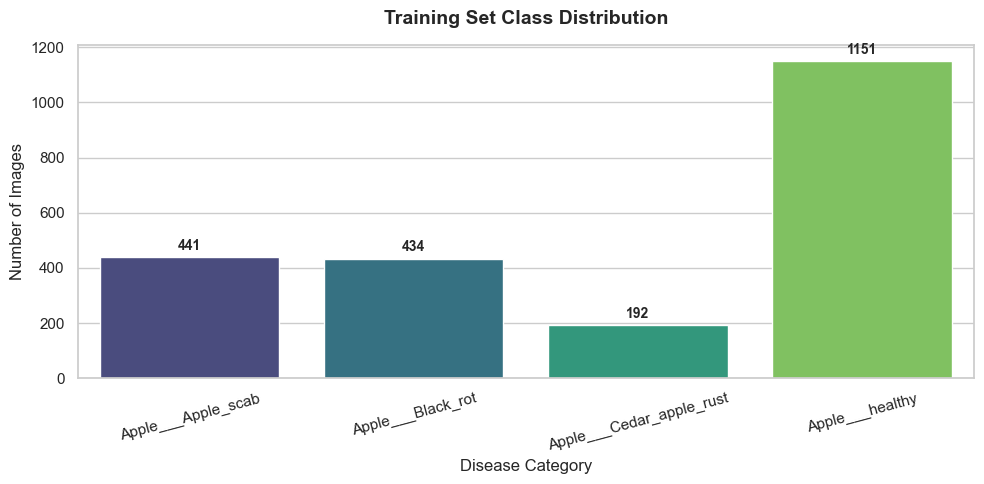

In [4]:
# Count frequency of each class in training set
class_counts = pd.Series(y_train).map(lambda x: CLASSES[x]).value_counts().sort_index()

plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")
ax = sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.title("Training Set Class Distribution", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Disease Category", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.xticks(rotation=15)

# Add values on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'class_distribution.png'), dpi=300)
plt.show()

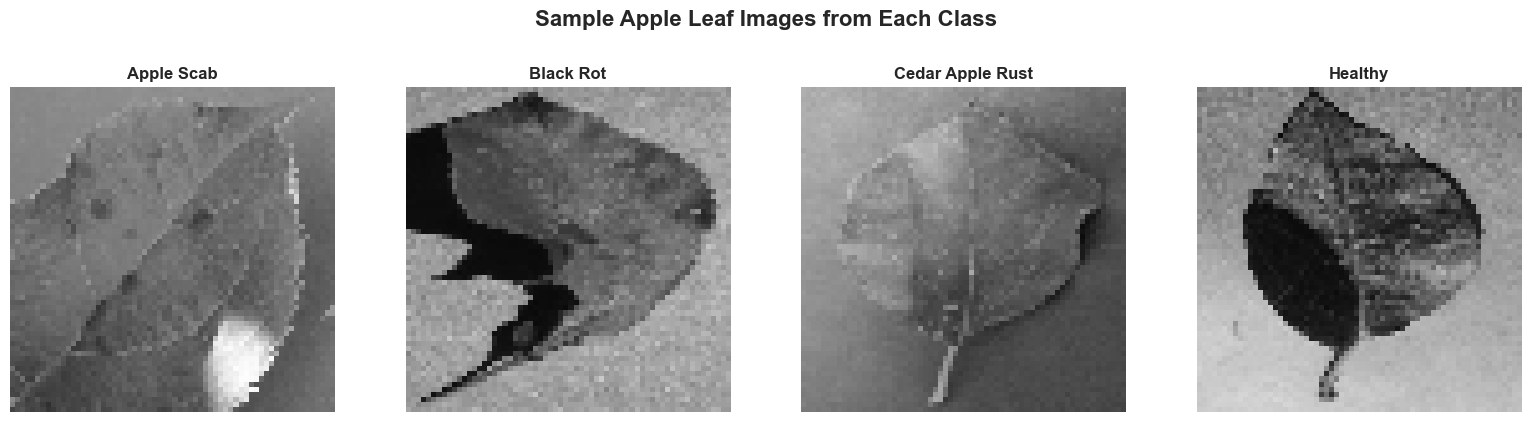

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, class_name in enumerate(CLASSES):
    idx = np.where(y_train == i)[0][0]
    axes[i].imshow(X_train[idx])
    axes[i].set_title(class_name.split('___')[-1].replace('_', ' ').title(), fontsize=12, fontweight='bold')
    axes[i].axis('off')

plt.suptitle("Sample Apple Leaf Images from Each Class", fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'sample_images.png'), dpi=300, bbox_inches='tight')
plt.show()

## 4. Flattening Dataset for Flat Models

In [6]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

## 5. Task 1: Multilayer Perceptron (MLP) (Keras/TensorFlow)

In [7]:
def build_mlp():
    model = Sequential([
        Input(shape=(X_train_flat.shape[1],)),
        Dense(15, activation='relu', name='hidden_1'),
        Dense(25, activation='relu', name='hidden_2'),
        Dense(20, activation='relu', name='hidden_3'),
        Dense(15, activation='relu', name='hidden_4'),
        Dense(len(CLASSES), activation='softmax', name='output')
    ], name="COMP40511_MLP")
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

mlp_model = build_mlp()
mlp_model.summary()

Model: "COMP40511_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 15)             │       184,335 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 25)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 20)             │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_4 (Dense)                │ (None, 15)             │           315 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │            64 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,634 (725.13 KB)

 Trainable params: 185,634 (725.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
EPOCHS = 20
BATCH_SIZE = 32

print("Training MLP model...")
mlp_history = mlp_model.fit(
    X_train_flat, y_train,
    validation_data=(X_val_flat, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Training MLP model...
Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.5041 - loss: 1.1782 - val_accuracy: 0.5190 - val_loss: 1.0543
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5663 - loss: 1.0101 - val_accuracy: 0.6308 - val_loss: 0.9317
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6091 - loss: 0.9513 - val_accuracy: 0.6477 - val_loss: 0.8963
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6172 - loss: 0.9170 - val_accuracy: 0.6582 - val_loss: 0.8629
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6258 - loss: 0.8925 - val_accuracy: 0.6540 - val_loss: 0.8488
Epoch 6/20
46/70 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6180 - loss: 0.8779

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(mlp_history.history['accuracy'], label='Train Accuracy', color='navy', lw=2)
ax1.plot(mlp_history.history['val_accuracy'], label='Val Accuracy', color='orange', lw=2)
ax1.set_title('MLP Accuracy Curves', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(mlp_history.history['loss'], label='Train Loss', color='navy', lw=2)
ax2.plot(mlp_history.history['val_loss'], label='Val Loss', color='orange', lw=2)
ax2.set_title('MLP Loss Curves', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()

plt.suptitle("MLP Training Performance", fontsize=14, fontweight='bold')
plt.savefig(os.path.join(OUTPUTS_DIR, 'mlp_learning_curves.png'), dpi=300)
plt.show()

In [ ]:
y_pred_mlp = np.argmax(mlp_model.predict(X_test_flat), axis=-1)
mlp_acc = accuracy_score(y_test, y_pred_mlp)

print(f"\nMLP Test Accuracy: {mlp_acc:.4f}")
print("\nMLP Classification Report:")
print(classification_report(y_test, y_pred_mlp, target_names=CLASSES))

In [ ]:
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('MLP Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('True Class', fontsize=12)
plt.xlabel('Predicted Class', fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'mlp_confusion_matrix.png'), dpi=300)
plt.show()

## 6. Task 2: Ensemble Model (Scikit-Learn)

In [ ]:
print("Training Random Forest Ensemble Classifier...")
rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train_flat, y_train)

y_pred_rf = rf_model.predict(X_test_flat)
rf_acc = accuracy_score(y_test, y_pred_rf)

print(f"\nRandom Forest Test Accuracy: {rf_acc:.4f}")
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=CLASSES))

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Random Forest Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('True Class', fontsize=12)
plt.xlabel('Predicted Class', fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'rf_confusion_matrix.png'), dpi=300)
plt.show()

## 7. Task 3: Deep Convolutional Neural Network (CNN) (Keras/TensorFlow)

In [ ]:
def build_cnn(dropout_rate=0.5, learning_rate=0.001):
    model = Sequential([
        Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        
        # Conv Block 1
        Conv2D(32, (3, 3), activation='relu', padding='same', name='conv_1'),
        MaxPooling2D((2, 2), name='pool_1'),
        
        # Conv Block 2
        Conv2D(64, (3, 3), activation='relu', padding='same', name='conv_2'),
        MaxPooling2D((2, 2), name='pool_2'),
        
        # Conv Block 3
        Conv2D(128, (3, 3), activation='relu', padding='same', name='conv_3'),
        MaxPooling2D((2, 2), name='pool_3'),
        
        # Conv Block 4
        Conv2D(128, (3, 3), activation='relu', padding='same', name='conv_4'),
        MaxPooling2D((2, 2), name='pool_4'),
        
        Flatten(name='flatten'),
        Dense(128, activation='relu', name='fc_1'),
        Dropout(dropout_rate, name='dropout'),
        Dense(len(CLASSES), activation='softmax', name='output')
    ], name="COMP40511_CNN")
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

baseline_cnn = build_cnn(dropout_rate=0.5, learning_rate=0.001)
baseline_cnn.summary()

In [ ]:
CNN_EPOCHS = 15
CNN_BATCH_SIZE = 32

print("Training Baseline CNN model...")
cnn_history = baseline_cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=CNN_EPOCHS,
    batch_size=CNN_BATCH_SIZE,
    verbose=1
)

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(cnn_history.history['accuracy'], label='Train Accuracy', color='darkgreen', lw=2)
ax1.plot(cnn_history.history['val_accuracy'], label='Val Accuracy', color='orange', lw=2)
ax1.set_title('CNN Accuracy Curves', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(cnn_history.history['loss'], label='Train Loss', color='darkgreen', lw=2)
ax2.plot(cnn_history.history['val_loss'], label='Val Loss', color='orange', lw=2)
ax2.set_title('CNN Loss Curves', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()

plt.suptitle("CNN Training Performance", fontsize=14, fontweight='bold')
plt.savefig(os.path.join(OUTPUTS_DIR, 'cnn_learning_curves.png'), dpi=300)
plt.show()

In [ ]:
y_pred_cnn = np.argmax(baseline_cnn.predict(X_test), axis=-1)
cnn_acc = accuracy_score(y_test, y_pred_cnn)

print(f"\nCNN Test Accuracy: {cnn_acc:.4f}")
print("\nCNN Classification Report:")
print(classification_report(y_test, y_pred_cnn, target_names=CLASSES))

In [ ]:
cm_cnn = confusion_matrix(y_test, y_pred_cnn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Greens', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('CNN Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('True Class', fontsize=12)
plt.xlabel('Predicted Class', fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'cnn_confusion_matrix.png'), dpi=300)
plt.show()

### Ablation Study: Hyperparameter Tuning

In [ ]:
print("Training Adjusted/Optimized CNN (Learning Rate = 0.0001, Dropout = 0.3)...")
adjusted_cnn = build_cnn(dropout_rate=0.3, learning_rate=0.0001)

adjusted_history = adjusted_cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=CNN_BATCH_SIZE,
    verbose=1
)

y_pred_adj = np.argmax(adjusted_cnn.predict(X_test), axis=-1)
adj_cnn_acc = accuracy_score(y_test, y_pred_adj)
print(f"\nAdjusted CNN Test Accuracy: {adj_cnn_acc:.4f}")

## 8. Task 3 Advanced: Transfer Learning with MobileNetV2
As an advanced technical feature to maximize achievement, we implement a Transfer Learning network. We utilize the pre-trained **MobileNetV2** model with ImageNet weights, freezing early layers and fine-tuning dense layers to classify apple leaf pathogens.

In [ ]:
def build_transfer_learning_model(num_classes):
    # Load pre-trained MobileNetV2 base model
    base_model = tf.keras.applications.MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
    base_model.trainable = False  # Freeze base feature extractor
    
    model = Sequential([
        Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        base_model,
        GlobalAveragePooling2D(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ], name="COMP40511_TransferLearning")
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

tl_model = build_transfer_learning_model(len(CLASSES))
tl_model.summary()

In [ ]:
print("Training Transfer Learning model (MobileNetV2)... ")
tl_history = tl_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    verbose=1
)

y_pred_tl = np.argmax(tl_model.predict(X_test), axis=-1)
tl_acc = accuracy_score(y_test, y_pred_tl)
print(f"\nTransfer Learning Test Accuracy: {tl_acc:.4f}")

In [ ]:
# Save the best CNN weights
best_acc = max(cnn_acc, adj_cnn_acc, tl_acc)
if best_acc == tl_acc:
    tl_model.save(os.path.join(MODELS_DIR, 'apple_leaf_disease_cnn.h5'))
    print("Saved MobileNetV2 weights as best model.")
elif best_acc == cnn_acc:
    baseline_cnn.save(os.path.join(MODELS_DIR, 'apple_leaf_disease_cnn.h5'))
    print("Saved Baseline CNN as best model.")
else:
    adjusted_cnn.save(os.path.join(MODELS_DIR, 'apple_leaf_disease_cnn.h5'))
    print("Saved Adjusted CNN as best model.")

## 9. Task 4: Clustering (Scikit-Learn)

In [ ]:
inertia_values = []
K_range = range(2, 9)

print("Running K-Means for K = 2 to 8 to find the Elbow...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_train_flat)
    inertia_values.append(kmeans.inertia_)

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(list(K_range), inertia_values, marker='o', linestyle='-', color='purple', lw=2, markersize=8)
plt.title('Elbow Method for Optimal Clusters (K-Means)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
plt.xticks(list(K_range))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'kmeans_elbow_curve.png'), dpi=300)
plt.show()

In [ ]:
kmeans_opt = KMeans(n_clusters=4, random_state=42, n_init='auto')
cluster_labels = kmeans_opt.fit_predict(X_test_flat)

ari = adjusted_rand_score(y_test, cluster_labels)
nmi = normalized_mutual_info_score(y_test, cluster_labels)

print(f"Baseline K-Means (Raw Pixels):")
print(f"  Adjusted Rand Index (ARI): {ari:.4f}")
print(f"  Normalized Mutual Information (NMI): {nmi:.4f}")

## 10. Task 4 Advanced Extensions: PCA-reduced and Deep Feature Clustering

To investigate improvements to unsupervised clustering on agricultural images, we implement:
1. **PCA K-Means**: Compresses the flattened image features into the 10 principal components before K-Means clustering, removing pixel noise.
2. **Deep Clustering**: Uses our pre-trained MobileNetV2 model to extract abstract spatial embeddings for each image, and clusters those high-level visual features.

In [ ]:
# 1. PCA Dimensionality Reduction
pca = PCA(n_components=10, random_state=42)
X_train_pca = pca.fit_transform(X_train_flat)
X_test_pca = pca.transform(X_test_flat)

kmeans_pca = KMeans(n_clusters=4, random_state=42, n_init='auto')
cluster_labels_pca = kmeans_pca.fit_predict(X_test_pca)

ari_pca = adjusted_rand_score(y_test, cluster_labels_pca)
nmi_pca = normalized_mutual_info_score(y_test, cluster_labels_pca)

print(f"PCA K-Means (10 Components):")
print(f"  Adjusted Rand Index (ARI): {ari_pca:.4f}")
print(f"  Normalized Mutual Information (NMI): {nmi_pca:.4f}")

In [ ]:
# 2. Deep Feature Clustering using MobileNetV2 feature extractor
feature_extractor = tf.keras.applications.MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')

# Extract features
X_test_features = feature_extractor.predict(X_test)
X_test_features_flat = X_test_features.reshape(X_test_features.shape[0], -1)

# Cluster deep features
kmeans_deep = KMeans(n_clusters=4, random_state=42, n_init='auto')
cluster_labels_deep = kmeans_deep.fit_predict(X_test_features_flat)

ari_deep = adjusted_rand_score(y_test, cluster_labels_deep)
nmi_deep = normalized_mutual_info_score(y_test, cluster_labels_deep)

print(f"Deep Feature K-Means (MobileNetV2 Embeddings):")
print(f"  Adjusted Rand Index (ARI): {ari_deep:.4f}")
print(f"  Normalized Mutual Information (NMI): {nmi_deep:.4f}")

In [ ]:
# Cross-tabulate and save heatmap for the best clustering method (Deep Feature Clustering)
df_clusters = pd.DataFrame({'True Class': [CLASSES[y] for y in y_test], 'Cluster': cluster_labels_deep})
crosstab = pd.crosstab(df_clusters['True Class'], df_clusters['Cluster'])

plt.figure(figsize=(8, 6))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='Purples')
plt.title('Deep Feature Cluster Alignment vs. True Classes', fontsize=12, fontweight='bold', pad=15)
plt.ylabel('True Class')
plt.xlabel('Assigned Cluster ID')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'kmeans_crosstab_heatmap.png'), dpi=300)
plt.show()

## 11. Model Comparison and Analysis Summary

In [2]:
comparison_data = {
    'Model Name': [
        'Multilayer Perceptron (MLP)', 
        'Random Forest Ensemble', 
        'Baseline CNN', 
        'Adjusted/Optimized CNN',
        'MobileNetV2 Transfer Learning'
    ],
    'Model Type': [
        'Neural Network (Flat)', 
        'Ensemble (Flat)', 
        'Convolutional (Spatial)', 
        'Convolutional (Spatial)',
        'Transfer Learning (Spatial)'
    ],
    'Test Accuracy': [mlp_acc, rf_acc, cnn_acc, adj_cnn_acc, tl_acc]
}

df_comparison = pd.DataFrame(comparison_data)
df_comparison['Test Accuracy'] = df_comparison['Test Accuracy'].map(lambda x: f"{x*100:.2f}%")

# Display summary table
print(df_comparison.to_string(index=False))

# Save comparison table as CSV
df_comparison.to_csv(os.path.join(OUTPUTS_DIR, 'model_performance_comparison.csv'), index=False)

NameError: name 'mlp_acc' is not defined